**Super-region code**

**Region clumping algorithm**

Brainstorm the super-region method to code tomorrow.
0. Start with region array of ones and zeros indicating where instabilities are located, as well as array identifying the indices of the region midpoints and endpoints. Create super-region array of zeros.
1. Beginning with the first region, calculate region width $L_0$ and midpoint $x_0$
2. Identify any subsequent region midpoint within $x_0 \pm L_0$ of the first region. If so, update super-region array to be one between $x_{min,0} - \Delta L$ and $x_{max,i} + \Delta L$, where $i$ is the index of the maximum captured region, and $\Delta L$ is some padding width.
3. Jump to next adjacent region outside of the newly created region, at $x_{i+1}$.
4. Return to step 1.

Test this below:

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import simpson

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1.
 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1.
 1. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]


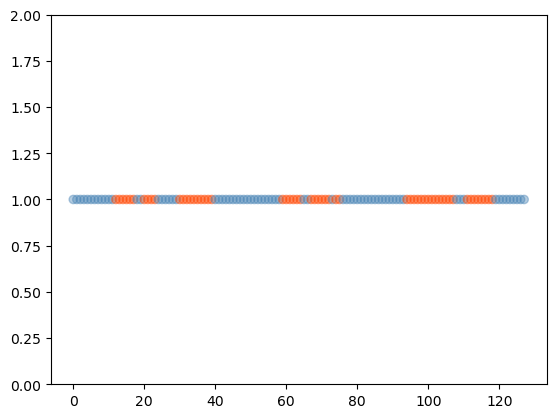

In [3]:

# create test instability array
stability_array = np.zeros(128)
test_midpoints = np.array([15, 22, 35, 62, 70, 75 , 101, 115])
test_half_widths = np.array([3, 2, 5, 3, 3, 1, 7, 4])

for i in range(len(test_midpoints)):
    stability_array[test_midpoints[i] - test_half_widths[i] : test_midpoints[i] + test_half_widths[i]] = 1

print(stability_array)

fig,ax = plt.subplots()
ax.scatter(np.arange(0,len(stability_array),1),np.ones_like(stability_array), c=np.where(stability_array == 1, "orangered", "steelblue"), alpha = 0.4)
ax.set(ylim=[0,2])
plt.show()